In [1]:
%pip install imbalanced-learn

In [19]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'   # silences the harmless joblib core-count warning

import pandas as pd, numpy as np, joblib, warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_validate
from sklearn.metrics import (accuracy_score, f1_score, log_loss, recall_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [25]:
LABELS = [0, 1, 2]   # 0 = Away, 1 = Draw, 2 = Home

def evaluate(model, X, y, name):
    pred = model.predict(X)
    rec = recall_score(y, pred, labels=LABELS, average=None, zero_division=0)
    out = {'model': name,
           'accuracy': accuracy_score(y, pred),
           'macro_f1': f1_score(y, pred, average='macro'),
           'recall_away': rec[0], 'recall_draw': rec[1], 'recall_home': rec[2]}
    if hasattr(model, 'predict_proba'):
        out['log_loss'] = log_loss(y, model.predict_proba(X), labels=LABELS)
    return out

ref = []
for strat in ['prior', 'stratified']:
    d = DummyClassifier(strategy=strat, random_state=42).fit(X_train, y_train)
    ref.append(evaluate(d, X_val, y_val, f'Dummy ({strat})'))
pd.DataFrame(ref).round(3)

,model,accuracy,macro_f1,recall_away,recall_draw,recall_home,log_loss
0,Dummy (prior),0.462,0.211,0.000,0.000,1.000,1.063
1,Dummy (stratified),0.363,0.329,0.298,0.205,0.484,22.954


In [29]:
MODELS = ['LogReg', 'DecisionTree', 'RandomForest', 'HistGB']
STRATEGIES = ['none', 'class_weight', 'smote', 'random_over', 'random_under']

def make_model(model_name, strategy):
    cw = 'balanced' if strategy == 'class_weight' else None
    if model_name == 'LogReg':          # baseline
        clf = LogisticRegression(max_iter=2000, class_weight=cw, random_state=42)
    elif model_name == 'DecisionTree':
        clf = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, class_weight=cw, random_state=42)
    elif model_name == 'RandomForest':
        clf = RandomForestClassifier(n_estimators=300, min_samples_leaf=10, class_weight=cw,
                                     random_state=42, n_jobs=-1)
    elif model_name == 'HistGB':
        clf = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200,
                                             class_weight=cw, random_state=42)
    steps = []
    if model_name == 'LogReg' or strategy == 'smote':
        steps.append(('scaler', StandardScaler()))   # fitted on training folds only, inside the pipeline
    if strategy == 'smote':        steps.append(('smote', SMOTE(random_state=42)))
    if strategy == 'random_over':  steps.append(('ros', RandomOverSampler(random_state=42)))
    if strategy == 'random_under': steps.append(('rus', RandomUnderSampler(random_state=42)))
    steps.append(('clf', clf))
    return ImbPipeline(steps)

In [31]:
rows = []
for m in MODELS:
    for s in STRATEGIES:
        pipe = make_model(m, s).fit(X_train, y_train)
        r = evaluate(pipe, X_val, y_val, f'{m} | {s}')
        r['train_acc'] = accuracy_score(y_train, pipe.predict(X_train))
        r['model_name'], r['strategy'] = m, s
        rows.append(r)

res = pd.DataFrame(rows)
cols = ['model', 'train_acc', 'accuracy', 'macro_f1', 'recall_away', 'recall_draw', 'recall_home', 'log_loss']
display(res[cols].sort_values('macro_f1', ascending=False).round(3))
for metric in ['macro_f1', 'recall_draw', 'log_loss', 'accuracy']:
    print('\n', metric)
    display(res.pivot(index='model_name', columns='strategy', values=metric).round(3))

,model,train_acc,accuracy,macro_f1,recall_away,recall_draw,recall_home,log_loss
12,RandomForest | smote,0.766,0.533,0.492,0.546,0.292,0.641,0.995
14,RandomForest | random_under,0.666,0.516,0.489,0.563,0.351,0.564,1.001
11,RandomForest | class_weight,0.745,0.525,0.487,0.534,0.304,0.627,0.993
17,HistGB | smote,0.679,0.530,0.478,0.508,0.246,0.684,1.048
1,LogReg | class_weight,0.487,0.522,0.476,0.597,0.240,0.610,1.005
4,LogReg | random_under,0.486,0.518,0.475,0.592,0.246,0.601,1.007
2,LogReg | smote,0.490,0.516,0.474,0.571,0.257,0.604,1.003
19,HistGB | random_under,0.677,0.499,0.471,0.529,0.327,0.561,1.081
13,RandomForest | random_over,0.799,0.508,0.470,0.517,0.287,0.610,1.005
16,HistGB | class_weight,0.686,0.504,0.469,0.534,0.292,0.587,1.080



 macro_f1


strategy,class_weight,none,random_over,random_under,smote
model_name,,,,,
DecisionTree,0.433,0.465,0.446,0.454,0.435
HistGB,0.469,0.442,0.442,0.471,0.478
LogReg,0.476,0.424,0.468,0.475,0.474
RandomForest,0.487,0.422,0.470,0.489,0.492



 recall_draw


strategy,class_weight,none,random_over,random_under,smote
model_name,,,,,
DecisionTree,0.556,0.175,0.135,0.526,0.380
HistGB,0.292,0.123,0.251,0.327,0.246
LogReg,0.240,0.047,0.234,0.246,0.257
RandomForest,0.304,0.047,0.287,0.351,0.292



 log_loss


strategy,class_weight,none,random_over,random_under,smote
model_name,,,,,
DecisionTree,1.569,2.039,1.503,1.459,1.683
HistGB,1.080,1.065,1.088,1.081,1.048
LogReg,1.005,0.978,1.006,1.007,1.003
RandomForest,0.993,0.979,1.005,1.001,0.995



 accuracy


strategy,class_weight,none,random_over,random_under,smote
model_name,,,,,
DecisionTree,0.432,0.545,0.526,0.459,0.450
HistGB,0.504,0.528,0.483,0.499,0.530
LogReg,0.522,0.550,0.513,0.518,0.516
RandomForest,0.525,0.546,0.508,0.516,0.533


In [32]:
tscv = TimeSeriesSplit(n_splits=4)
cv_rows = []
for m in MODELS:
    for s in STRATEGIES:
        cv = cross_validate(make_model(m, s), X_train, y_train, cv=tscv, n_jobs=-1,
                            scoring={'macro_f1': 'f1_macro', 'acc': 'accuracy', 'neg_ll': 'neg_log_loss'})
        cv_rows.append({'model_name': m, 'strategy': s,
                        'cv_macro_f1': cv['test_macro_f1'].mean(), 'cv_macro_f1_std': cv['test_macro_f1'].std(),
                        'cv_acc': cv['test_acc'].mean(), 'cv_log_loss': -cv['test_neg_ll'].mean()})
cv_res = pd.DataFrame(cv_rows)
display(cv_res.sort_values('cv_macro_f1', ascending=False).round(3))
display(cv_res.pivot(index='model_name', columns='strategy', values='cv_macro_f1').round(3))

,model_name,strategy,cv_macro_f1,cv_macro_f1_std,cv_acc,cv_log_loss
4,LogReg,random_under,0.458,0.035,0.493,1.064
1,LogReg,class_weight,0.446,0.022,0.486,1.051
2,LogReg,smote,0.442,0.026,0.480,1.060
3,LogReg,random_over,0.438,0.023,0.476,1.055
11,RandomForest,class_weight,0.427,0.045,0.465,1.025
18,HistGB,random_over,0.427,0.033,0.463,1.178
13,RandomForest,random_over,0.427,0.037,0.464,1.033
14,RandomForest,random_under,0.424,0.037,0.445,1.039
12,RandomForest,smote,0.419,0.047,0.452,1.039
6,DecisionTree,class_weight,0.418,0.046,0.434,1.748


strategy,class_weight,none,random_over,random_under,smote
model_name,,,,,
DecisionTree,0.418,0.403,0.408,0.403,0.408
HistGB,0.417,0.405,0.427,0.397,0.414
LogReg,0.446,0.387,0.438,0.458,0.442
RandomForest,0.427,0.389,0.427,0.424,0.419


In [11]:
tscv = TimeSeriesSplit(n_splits=4)
cv_rows = []
for m in MODELS:
    for s in STRATEGIES:
        cv = cross_validate(make_model(m, s), X_train, y_train, cv=tscv, n_jobs=-1,
                            scoring={'macro_f1': 'f1_macro', 'acc': 'accuracy', 'neg_ll': 'neg_log_loss'})
        cv_rows.append({'model_name': m, 'strategy': s,
                        'cv_macro_f1': cv['test_macro_f1'].mean(), 'cv_macro_f1_std': cv['test_macro_f1'].std(),
                        'cv_acc': cv['test_acc'].mean(), 'cv_log_loss': -cv['test_neg_ll'].mean()})
cv_res = pd.DataFrame(cv_rows)
display(cv_res.sort_values('cv_macro_f1', ascending=False).round(3))
display(cv_res.pivot(index='model_name', columns='strategy', values='cv_macro_f1').round(3))

,model_name,strategy,cv_macro_f1,cv_macro_f1_std,cv_acc,cv_log_loss
3,LogReg,random_over,0.402,0.033,0.430,1.069
2,LogReg,smote,0.401,0.032,0.424,1.073
1,LogReg,class_weight,0.399,0.030,0.428,1.067
14,RandomForest,random_under,0.395,0.026,0.408,1.070
4,LogReg,random_under,0.393,0.039,0.413,1.078
13,RandomForest,random_over,0.392,0.028,0.424,1.062
12,RandomForest,smote,0.391,0.037,0.412,1.065
11,RandomForest,class_weight,0.390,0.032,0.418,1.055
8,DecisionTree,random_over,0.387,0.011,0.399,1.366
17,HistGB,smote,0.387,0.040,0.411,1.186


strategy,class_weight,none,random_over,random_under,smote
model_name,,,,,
DecisionTree,0.373,0.384,0.387,0.366,0.381
HistGB,0.376,0.367,0.386,0.375,0.387
LogReg,0.399,0.348,0.402,0.393,0.401
RandomForest,0.390,0.345,0.392,0.395,0.391


In [34]:
BEST_STRATEGY = 'class_weight'

grids = {
    'LogReg':       {'clf__C': [0.01, 0.1, 1, 10]},
    'DecisionTree': {'clf__max_depth': [3, 4, 5, 7], 'clf__min_samples_leaf': [10, 20, 40]},
    'RandomForest': {'clf__n_estimators': [200, 400], 'clf__max_depth': [4, 6, 8, None],
                     'clf__min_samples_leaf': [5, 10, 20]},
    'HistGB':       {'clf__max_depth': [2, 3, 4], 'clf__learning_rate': [0.03, 0.05, 0.1],
                     'clf__max_iter': [100, 200]},
}

tuned, tuned_rows = {}, []
for m, grid in grids.items():
    gs = GridSearchCV(make_model(m, BEST_STRATEGY), grid, cv=tscv, scoring='f1_macro', n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned[m] = gs.best_estimator_
    print(f'{m}: best CV macro-F1 = {gs.best_score_:.3f} | {gs.best_params_}')
    tuned_rows.append(evaluate(gs.best_estimator_, X_val, y_val, f'{m} (tuned, {BEST_STRATEGY})'))

tuned_res = pd.DataFrame(tuned_rows)
display(tuned_res.sort_values('macro_f1', ascending=False).round(3))

LogReg: best CV macro-F1 = 0.446 | {'clf__C': 1}
DecisionTree: best CV macro-F1 = 0.441 | {'clf__max_depth': 3, 'clf__min_samples_leaf': 20}
RandomForest: best CV macro-F1 = 0.453 | {'clf__max_depth': 4, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 400}
HistGB: best CV macro-F1 = 0.438 | {'clf__learning_rate': 0.03, 'clf__max_depth': 2, 'clf__max_iter': 100}


,model,accuracy,macro_f1,recall_away,recall_draw,recall_home,log_loss
2,"RandomForest (tuned, class_weight)",0.509,0.487,0.550,0.374,0.547,0.995
3,"HistGB (tuned, class_weight)",0.504,0.482,0.580,0.357,0.524,1.010
0,"LogReg (tuned, class_weight)",0.522,0.476,0.597,0.240,0.610,1.005
1,"DecisionTree (tuned, class_weight)",0.480,0.474,0.534,0.474,0.447,1.417


Best on validation: RandomForest
              precision    recall  f1-score   support

        Away       0.50      0.55      0.52       238
        Draw       0.30      0.37      0.33       171
        Home       0.68      0.55      0.60       351

    accuracy                           0.51       760
   macro avg       0.49      0.49      0.49       760
weighted avg       0.54      0.51      0.52       760



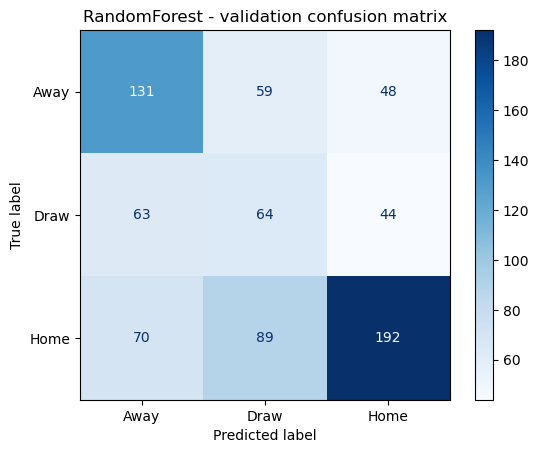

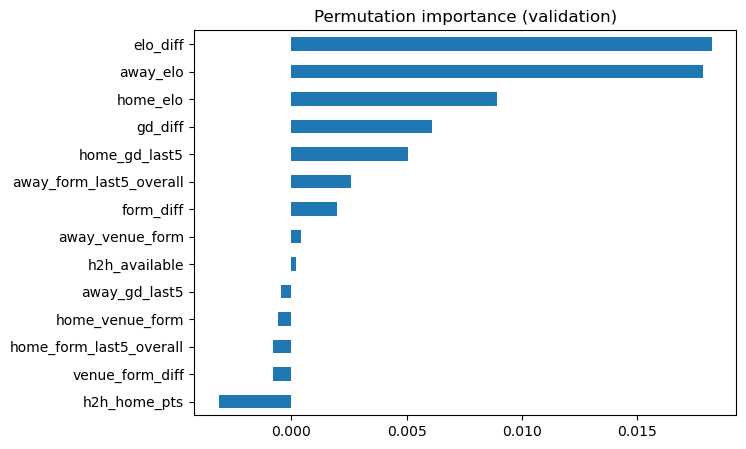

In [35]:
best_name = tuned_res.sort_values('macro_f1', ascending=False).iloc[0]['model'].split(' ')[0]
best_model = tuned[best_name]
print('Best on validation:', best_name)

pred = best_model.predict(X_val)
print(classification_report(y_val, pred, target_names=['Away', 'Draw', 'Home'], zero_division=0))

ConfusionMatrixDisplay(confusion_matrix(y_val, pred), display_labels=['Away', 'Draw', 'Home']).plot(cmap='Blues')
plt.title(f'{best_name} - validation confusion matrix')
plt.show()

pi = permutation_importance(best_model, X_val, y_val, scoring='f1_macro', n_repeats=10, random_state=42)
pd.Series(pi.importances_mean, index=features).sort_values().plot(kind='barh', figsize=(7, 5))
plt.title('Permutation importance (validation)')
plt.show()

In [39]:
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../models', exist_ok=True)

res.to_csv(f'../outputs/strategy_comparison_val_{TAG}.csv', index=False)
cv_res.to_csv(f'../outputs/strategy_comparison_cv_{TAG}.csv', index=False)
tuned_res.to_csv(f'../outputs/model_comparison_{TAG}.csv', index=False)
for m, mdl in tuned.items():
    joblib.dump(mdl, f'../models/{TAG}_{m}_tuned.joblib')
pd.Series(features).to_csv(f'../data/processed/feature_list_{TAG}.csv', index=False, header=['feature'])
print('Saved with tag:', TAG, '| test.csv was never loaded in this notebook.')

Saved with tag: elo | test.csv was never loaded in this notebook.
